# Playground Series S6E4 — Predicting Irrigation Need

**Task:** Multiclass classification (Low / Medium / High)  
**Rows:** 630k train, 270k test  
**Features:** 19 (11 numeric, 8 categorical)  
**No missing values**

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import accuracy_score, classification_report
from sklearn.preprocessing import LabelEncoder
import lightgbm as lgb
import warnings
warnings.filterwarnings('ignore')

DATA_DIR = 'data'
SEED = 42
N_FOLDS = 5

## 1. Load Data

In [2]:
train = pd.read_csv(f'{DATA_DIR}/train.csv')
test = pd.read_csv(f'{DATA_DIR}/test.csv')
submission = pd.read_csv(f'{DATA_DIR}/sample_submission.csv')

print(f'Train: {train.shape}, Test: {test.shape}')
train.head()

Train: (630000, 21), Test: (270000, 20)


,id,Soil_Type,Soil_pH,Soil_Moisture,Organic_Carbon,Electrical_Conductivity,Temperature_C,Humidity,Rainfall_mm,Sunlight_Hours,...,Crop_Type,Crop_Growth_Stage,Season,Irrigation_Type,Water_Source,Field_Area_hectare,Mulching_Used,Previous_Irrigation_mm,Region,Irrigation_Need
0,0,Loamy,4.92,32.58,1.01,3.05,15.01,50.61,725.99,5.90,...,Sugarcane,Sowing,Zaid,Drip,Rainwater,0.82,No,112.16,East,Low
1,1,Clay,7.08,56.61,0.44,2.00,22.92,67.86,985.66,6.98,...,Wheat,Vegetative,Kharif,Rainfed,River,5.27,Yes,47.16,South,Low
2,2,Clay,5.69,27.71,0.81,2.83,26.97,92.22,2201.70,6.05,...,Rice,Vegetative,Kharif,Sprinkler,Reservoir,8.24,Yes,110.38,North,Low
3,3,Sandy,5.65,13.32,1.33,0.87,13.32,61.57,1357.33,9.12,...,Wheat,Flowering,Kharif,Canal,River,8.32,Yes,53.85,South,Medium
4,4,Clay,7.96,59.14,0.38,0.96,20.22,91.11,1538.20,6.95,...,Wheat,Sowing,Rabi,Canal,River,7.37,No,93.19,South,Low


## 2. EDA

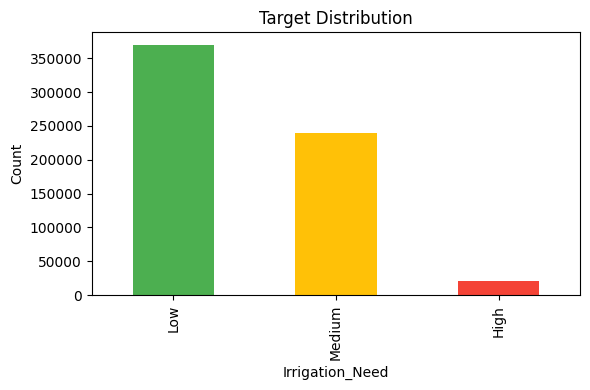

Irrigation_Need
Low       0.5872
Medium    0.3795
High      0.0333
Name: proportion, dtype: float64


In [3]:
# Target distribution
fig, ax = plt.subplots(1, 1, figsize=(6, 4))
train['Irrigation_Need'].value_counts().plot(kind='bar', ax=ax, color=['#4CAF50', '#FFC107', '#F44336'])
ax.set_title('Target Distribution')
ax.set_ylabel('Count')
plt.tight_layout()
plt.show()

print(train['Irrigation_Need'].value_counts(normalize=True).round(4))

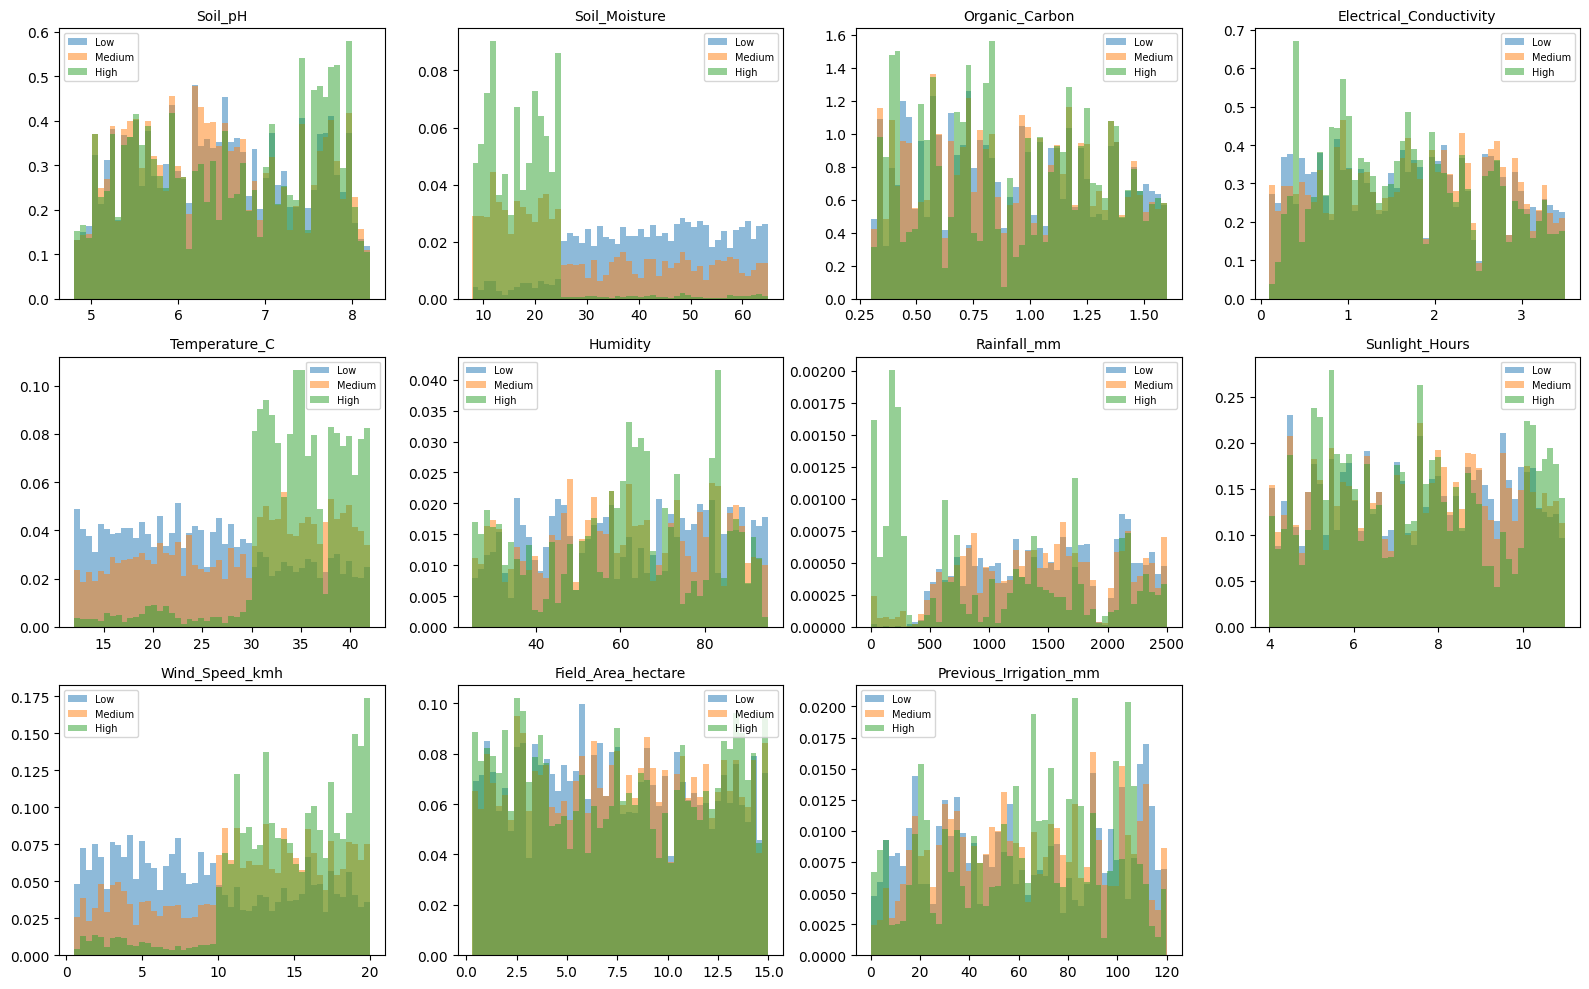

In [4]:
# Numeric feature distributions
num_cols = train.select_dtypes(include='number').columns.drop('id')
fig, axes = plt.subplots(3, 4, figsize=(16, 10))
for i, col in enumerate(num_cols):
    ax = axes[i // 4, i % 4]
    for label in ['Low', 'Medium', 'High']:
        subset = train[train['Irrigation_Need'] == label][col]
        ax.hist(subset, bins=50, alpha=0.5, label=label, density=True)
    ax.set_title(col, fontsize=10)
    ax.legend(fontsize=7)
# hide empty subplots
for j in range(len(num_cols), 12):
    axes[j // 4, j % 4].set_visible(False)
plt.tight_layout()
plt.show()

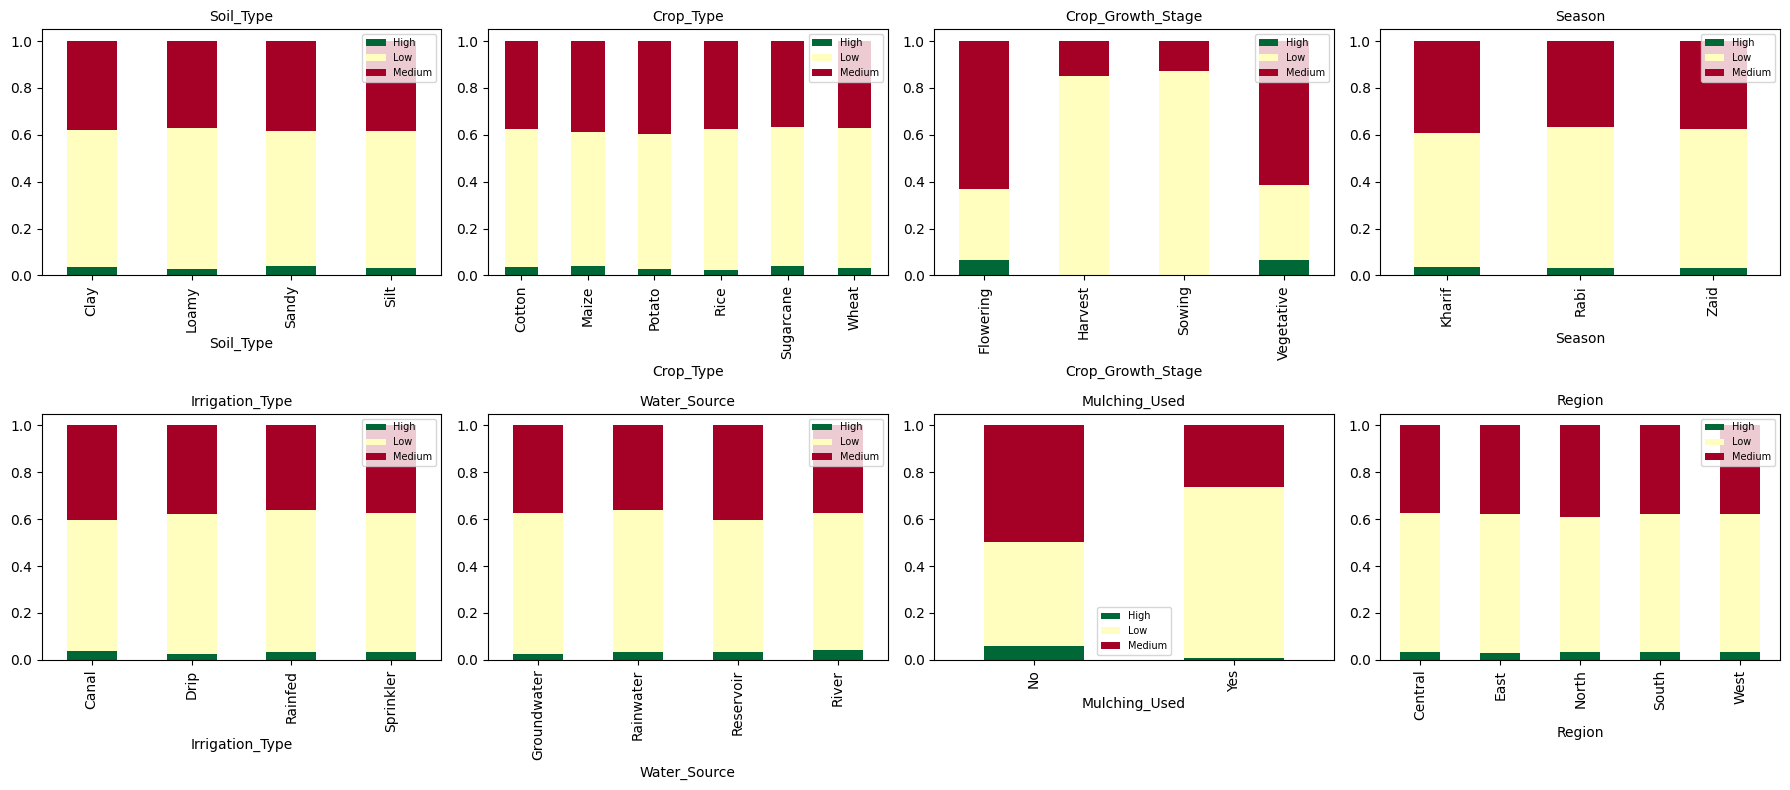

In [5]:
# Categorical feature vs target
cat_cols = ['Soil_Type', 'Crop_Type', 'Crop_Growth_Stage', 'Season',
            'Irrigation_Type', 'Water_Source', 'Mulching_Used', 'Region']

fig, axes = plt.subplots(2, 4, figsize=(18, 8))
for i, col in enumerate(cat_cols):
    ax = axes[i // 4, i % 4]
    pd.crosstab(train[col], train['Irrigation_Need'], normalize='index').plot(
        kind='bar', stacked=True, ax=ax, colormap='RdYlGn_r'
    )
    ax.set_title(col, fontsize=10)
    ax.legend(fontsize=7)
    ax.set_ylabel('')
plt.tight_layout()
plt.show()

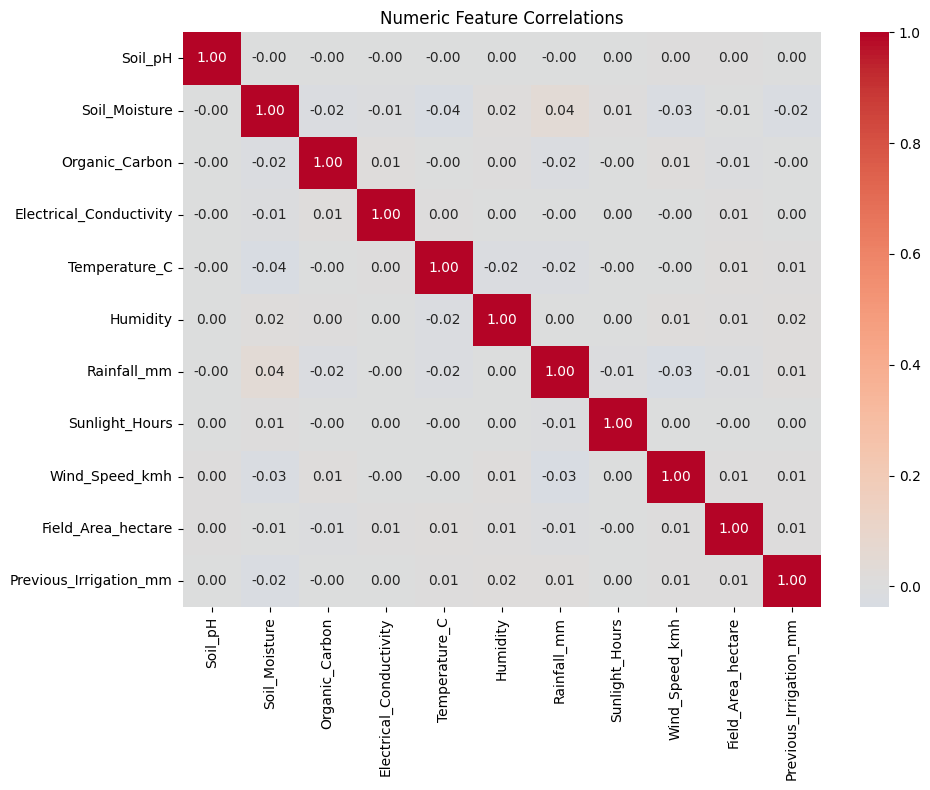

In [6]:
# Correlation heatmap
fig, ax = plt.subplots(figsize=(10, 8))
corr = train[num_cols].corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0, ax=ax)
ax.set_title('Numeric Feature Correlations')
plt.tight_layout()
plt.show()

## 3. Preprocessing

In [7]:
# Encode target
target_map = {'Low': 0, 'Medium': 1, 'High': 2}
y = train['Irrigation_Need'].map(target_map)

# Features
drop_cols = ['id', 'Irrigation_Need']
X = train.drop(columns=drop_cols)
X_test = test.drop(columns=['id'])

# Mark categorical columns for LightGBM native support
for col in cat_cols:
    X[col] = X[col].astype('category')
    X_test[col] = X_test[col].astype('category')

print(f'X: {X.shape}, y: {y.shape}, X_test: {X_test.shape}')

X: (630000, 19), y: (630000,), X_test: (270000, 19)


## 4. LightGBM with Stratified K-Fold

In [8]:
lgb_params = {
    'objective': 'multiclass',
    'num_class': 3,
    'metric': 'multi_logloss',
    'learning_rate': 0.05,
    'num_leaves': 63,
    'max_depth': -1,
    'min_child_samples': 50,
    'subsample': 0.8,
    'colsample_bytree': 0.8,
    'reg_alpha': 0.1,
    'reg_lambda': 1.0,
    'random_state': SEED,
    'verbose': 1,
    'n_estimators': 2000,
}

skf = StratifiedKFold(n_splits=N_FOLDS, shuffle=True, random_state=SEED)

oof_preds = np.zeros((len(X), 3))
test_preds = np.zeros((len(X_test), 3))
fold_scores = []

for fold, (train_idx, val_idx) in enumerate(skf.split(X, y)):
    X_train, X_val = X.iloc[train_idx], X.iloc[val_idx]
    y_train, y_val = y.iloc[train_idx], y.iloc[val_idx]

    model = lgb.LGBMClassifier(**lgb_params)
    model.fit(
        X_train, y_train,
        eval_set=[(X_val, y_val)],
        callbacks=[
            lgb.early_stopping(100, verbose=True),
            lgb.log_evaluation(200),
        ],
    )

    oof_preds[val_idx] = model.predict_proba(X_val)
    test_preds += model.predict_proba(X_test) / N_FOLDS

    fold_acc = accuracy_score(y_val, oof_preds[val_idx].argmax(axis=1))
    fold_scores.append(fold_acc)
    print(f'Fold {fold}: Accuracy = {fold_acc:.5f} | Best iter = {model.best_iteration_}')

print(f'\nCV Accuracy: {np.mean(fold_scores):.5f} ± {np.std(fold_scores):.5f}')

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.058799 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 2704
[LightGBM] [Info] Number of data points in the train set: 504000, number of used features: 19
[LightGBM] [Info] Start training from score -0.532443
[LightGBM] [Info] Start training from score -0.968948
[LightGBM] [Info] Start training from score -3.400721
Training until validation scores don't improve for 100 rounds
[200]	valid_0's multi_logloss: 0.058837
[400]	valid_0's multi_logloss: 0.0575254
[600]	valid_0's multi_logloss: 0.0574059
Early stopping, best iteration is:
[564]	valid_0's multi_logloss: 0.0573877
Fold 0: Accuracy = 0.98425 | Best iter = 564
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.068165 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 2705
[LightGBM] [Info] Number of data points in the 

In [9]:
# OOF classification report
inv_map = {v: k for k, v in target_map.items()}
oof_labels = pd.Series(oof_preds.argmax(axis=1)).map(inv_map)
true_labels = y.map(inv_map)
print(classification_report(true_labels, oof_labels))

              precision    recall  f1-score   support

        High       0.97      0.92      0.94     21009
         Low       0.99      0.99      0.99    369917
      Medium       0.98      0.97      0.98    239074

    accuracy                           0.98    630000
   macro avg       0.98      0.96      0.97    630000
weighted avg       0.98      0.98      0.98    630000



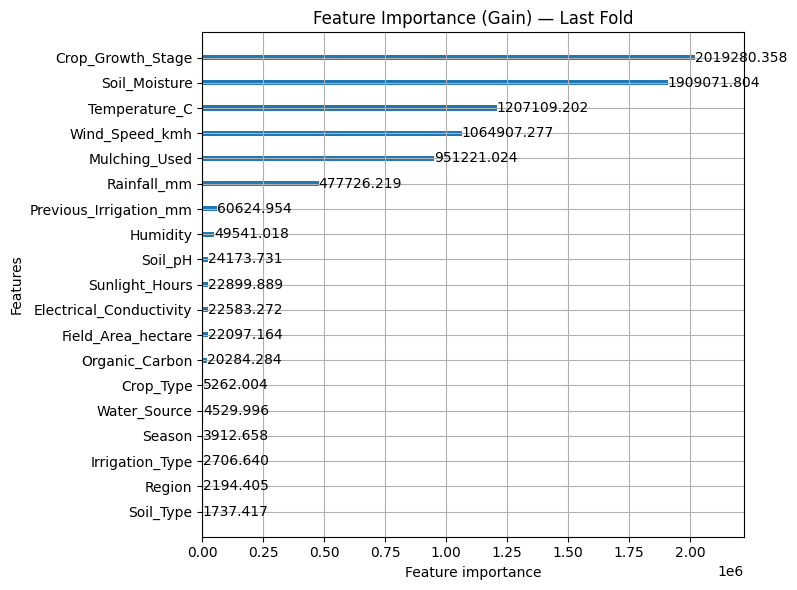

In [10]:
# Feature importance
fig, ax = plt.subplots(figsize=(8, 6))
lgb.plot_importance(model, max_num_features=19, ax=ax, importance_type='gain')
ax.set_title('Feature Importance (Gain) — Last Fold')
plt.tight_layout()
plt.show()

## 5. Submission

In [11]:
submission['Irrigation_Need'] = pd.Series(test_preds.argmax(axis=1)).map(inv_map)
submission.to_csv('submission.csv', index=False)

print(submission['Irrigation_Need'].value_counts())
submission.head()

Irrigation_Need
Low       159855
Medium    101524
High        8621
Name: count, dtype: int64


,id,Irrigation_Need
0,630000,Low
1,630001,Low
2,630002,Low
3,630003,Low
4,630004,Low
